## 0. Environment Setup

In [ ]:
# 0. Environment Setup
# ─────────────────────────────────────────────
!pip install -q "transformers>=4.40.0" sentencepiece protobuf datasets accelerate


In [4]:
# Imports and global seed
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_curve, classification_report
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
# Expected: "Using device: cuda"

/rds/general/user/ss9323/home/myvenv/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## 1. Data Loading

Data sources:
- `dontpatronizeme_pcl.tsv` — main labelled dataset (upload manually when prompted)
- Train/dev split index files — downloaded from official GitHub
- `task4_test.tsv` — official unlabelled test set (3832 examples)

In [1]:
# 1.1 — Download split index files and test set
import subprocess

urls = {
    'train_semeval_parids-labels.csv': 'https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/practice%20splits/train_semeval_parids-labels.csv',
    'dev_semeval_parids-labels.csv':   'https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/practice%20splits/dev_semeval_parids-labels.csv',
    'task4_test.tsv':                  'https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/TEST/task4_test.tsv',
}
for fname, url in urls.items():
    subprocess.run(['wget', '-q', '-O', fname, url], check=True)
    print(f"✓ Downloaded {fname}")


✓ Downloaded train_semeval_parids-labels.csv
✓ Downloaded dev_semeval_parids-labels.csv
✓ Downloaded task4_test.tsv


In [2]:
# 1.2 — Download dontpatronizeme_pcl.tsv directly
subprocess.run([
    'wget', '-q', '-O', 'dontpatronizeme_pcl.tsv',
    'https://raw.githubusercontent.com/CRLala/NLPLabs-2024/main/Dont_Patronize_Me_Trainingset/dontpatronizeme_pcl.tsv'
], check=True)
print("✓ Downloaded dontpatronizeme_pcl.tsv")


✓ Downloaded dontpatronizeme_pcl.tsv


In [5]:
# 1.3 — Load dontpatronizeme_pcl.tsv directly with pandas
# File has 4 header rows (disclaimer banner + description + separator + blank line) → skiprows=4
# Columns: par_id, art_id, keyword, country, text, orig_label (0-4 annotation scale)
# Binary label: orig_label >= 2 → PCL (1), else No-PCL (0)

import re

def clean_text(text):
    """
    Fix spaced-out contractions and punctuation artefacts in the dataset.
    e.g. "isn 't" → "isn't", "he 's" → "he's", "do n't" → "don't"
    This aligns the text with RoBERTa's pretraining distribution (standard English).
    """
    # 1. Fix "word n 't" → "wordn't" FIRST (e.g. "do n 't" → "don't", "could n 't" → "couldn't")
    text = re.sub(r"(\w)\s+n\s*'t\b", r"\1n't", text)
    # 2. Fix remaining spaced contractions: 't, 's, 're, 've, 'll, 'd, 'm
    text = re.sub(r"\s+'(t|s|re|ve|ll|d|m)\b", r"'\1", text)
    # 3. Fix spaced punctuation: word , word → word, word
    text = re.sub(r'\s+([,\.;:!\?])', r'\1', text)
    # 4. Collapse multiple spaces
    text = re.sub(r'\s{2,}', ' ', text)
    return text.strip()

full_df = pd.read_csv('dontpatronizeme_pcl.tsv', sep='\t', header=None, skiprows=4,
                       names=['par_id', 'art_id', 'keyword', 'country', 'text', 'orig_label'])
full_df['text'] = full_df['text'].fillna('')          # tokenizer requires strings, not NaN
full_df['text'] = full_df['text'].apply(clean_text)   # fix spaced contractions
full_df['label'] = (full_df['orig_label'] >= 2).astype(int)

print(f"Total labelled samples : {len(full_df)}")
print(f"Label value counts     :\n{full_df['label'].value_counts().sort_index()}")

# Show cleaning effect
print("\n--- Text cleaning examples ---")
raw_examples = ["We 're living in times of absolute insanity ,",
                "He said it isn 't going to work .",
                "They do n't have access to clean water .",
                "She could n't believe what she 'd seen ."]
for raw in raw_examples:
    print(f"  {raw!r:55s} → {clean_text(raw)!r}")

full_df.head(3)

Total labelled samples : 10469
Label value counts     :
label
0    9476
1     993
Name: count, dtype: int64

--- Text cleaning examples ---
  "We 're living in times of absolute insanity ,"         → "We're living in times of absolute insanity,"
  "He said it isn 't going to work ."                     → "He said it isn't going to work."
  "They do n't have access to clean water ."              → "They don't have access to clean water."
  "She could n't believe what she 'd seen ."              → "She couldn't believe what she'd seen."


,par_id,art_id,keyword,country,text,orig_label,label
0,1,@@24942188,hopeless,ph,"We're living in times of absolute insanity, as...",0,0
1,2,@@21968160,migrant,gh,"In Libya today, there are countless number of ...",0,0
2,3,@@16584954,immigrant,ie,White House press secretary Sean Spicer said t...,0,0


In [6]:
# 1.4 — Apply official train/dev split by par_id, then carve out a validation set from train
from sklearn.model_selection import train_test_split

train_split = pd.read_csv('train_semeval_parids-labels.csv')
dev_split   = pd.read_csv('dev_semeval_parids-labels.csv')

train_ids = set(train_split['par_id'].values)
dev_ids   = set(dev_split['par_id'].values)

train_full_df = full_df[full_df['par_id'].isin(train_ids)].reset_index(drop=True)
dev_df        = full_df[full_df['par_id'].isin(dev_ids)].reset_index(drop=True)

# Split train into train (90%) + val (10%), stratified by label to preserve class ratio
# Val is used for early stopping during training
# Dev (official) is reserved exclusively for threshold tuning — no data leak
train_df, val_df = train_test_split(
    train_full_df, test_size=0.1, random_state=SEED, stratify=train_full_df['label']
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Train : {len(train_df):,} examples | PCL={train_df['label'].sum():,} ({100*train_df['label'].mean():.1f}%)")
print(f"Val   : {len(val_df):,}   examples | PCL={val_df['label'].sum():,}  ({100*val_df['label'].mean():.1f}%)  ← for early stopping")
print(f"Dev   : {len(dev_df):,}  examples | PCL={dev_df['label'].sum():,}   ({100*dev_df['label'].mean():.1f}%)  ← for threshold tuning only")

Train : 7,537 examples | PCL=715 (9.5%)
Val   : 838   examples | PCL=79  (9.4%)  ← for early stopping
Dev   : 2,094  examples | PCL=199   (9.5%)  ← for threshold tuning only


In [7]:
# 1.5 — Load official test set directly with pandas (no labels)
test_df = pd.read_csv('task4_test.tsv', sep='\t', header=None,
                       names=['par_id', 'art_id', 'keyword', 'country', 'text'])
test_df['text'] = test_df['text'].fillna('').apply(clean_text)

print(f"Test set size: {len(test_df):,} examples  (expected 3,832)")
test_df.head(3)

Test set size: 3,832 examples  (expected 3,832)


,par_id,art_id,keyword,country,text
0,t_0,@@7258997,vulnerable,us,"In the meantime, conservatives are working to ..."
1,t_1,@@16397324,women,pk,In most poor households with no education chil...
2,t_2,@@16257812,migrant,ca,The real question is not whether immigration i...


## 2. Exploratory Data Analysis (EDA)

### Exercise 2: Two distinct EDA techniques

**Technique 1** — Class Distribution & Text Length Analysis  
**Technique 2** — N-gram Frequency Analysis by Class

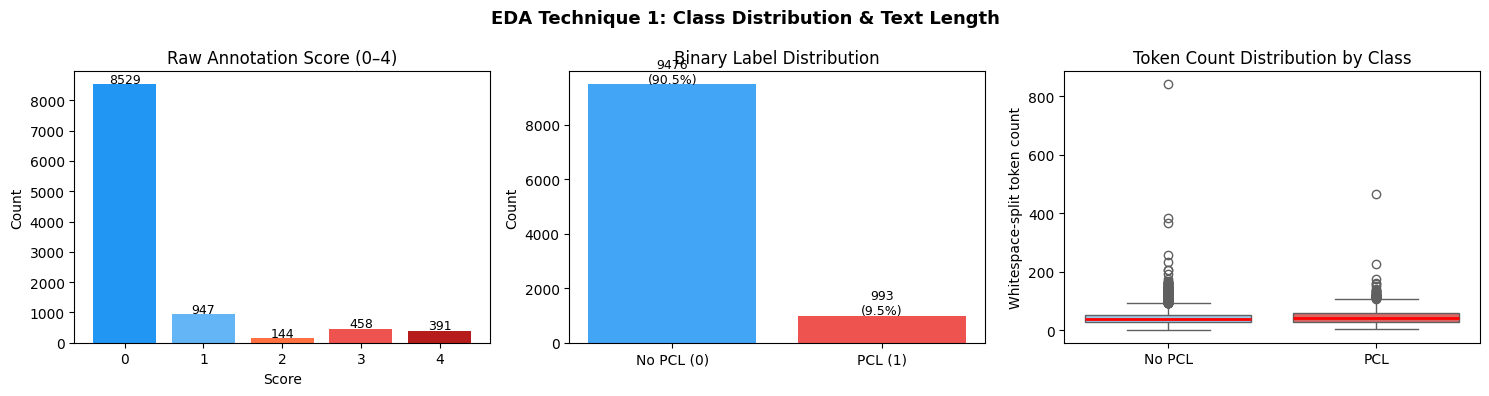

=== Token Count Statistics ===
  No PCL: mean=43.5, median=38, max=843, p95=91
  PCL: mean=48.6, median=42, max=465, p95=102

Class imbalance: 9.5% PCL vs 90.5% No-PCL
→ Severe imbalance motivates focal loss and threshold tuning in our novel approach.
→ p95 token count is within 256 → max_len=256 is appropriate.


In [8]:
# EDA Technique 1: Class Distribution & Text Length Analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('EDA Technique 1: Class Distribution & Text Length', fontsize=13, fontweight='bold')

# Plot 1: raw annotation score distribution (0-4)
orig_counts = full_df['orig_label'].value_counts().sort_index()
bars = axes[0].bar(orig_counts.index.astype(str), orig_counts.values,
                   color=['#2196F3','#64B5F6','#FF7043','#EF5350','#B71C1C'])
axes[0].set_title('Raw Annotation Score (0\u20134)')
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Count')
for bar, v in zip(bars, orig_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 50, str(v), ha='center', fontsize=9)

# Plot 2: binary label distribution
bin_counts = full_df['label'].value_counts().sort_index()
bars2 = axes[1].bar(['No PCL (0)', 'PCL (1)'], bin_counts.values, color=['#42A5F5','#EF5350'])
axes[1].set_title('Binary Label Distribution')
axes[1].set_ylabel('Count')
for bar, v in zip(bars2, bin_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 50,
                 f"{v}\n({100*v/len(full_df):.1f}%)", ha='center', fontsize=9)

# Plot 3: token count distribution by class (seaborn handles NaN and pandas DataFrames natively)
full_df['token_count'] = full_df['text'].str.split().str.len()
bp_df = full_df[['label', 'token_count']].dropna().copy()
bp_df['Class'] = bp_df['label'].map({0: 'No PCL', 1: 'PCL'})

sns.boxplot(data=bp_df, x='Class', y='token_count', order=['No PCL', 'PCL'],
            palette={'No PCL': '#90CAF9', 'PCL': '#EF5350'},
            medianprops=dict(color='red', linewidth=2), ax=axes[2])
axes[2].set_title('Token Count Distribution by Class')
axes[2].set_ylabel('Whitespace-split token count')
axes[2].set_xlabel('')

plt.tight_layout()
plt.savefig('eda_technique1.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Token Count Statistics ===")
for label, name in [(0, 'No PCL'), (1, 'PCL')]:
    s = full_df[full_df['label']==label]['token_count'].dropna()
    print(f"  {name}: mean={s.mean():.1f}, median={s.median():.0f}, max={s.max()}, p95={s.quantile(0.95):.0f}")

pcl_pct = 100 * full_df['label'].mean()
print(f"\nClass imbalance: {pcl_pct:.1f}% PCL vs {100-pcl_pct:.1f}% No-PCL")
print("\u2192 Severe imbalance motivates focal loss and threshold tuning in our novel approach.")
print(f"\u2192 p95 token count is within 256 \u2192 max_len=256 is appropriate.")

**EDA Technique 1 — Analysis & Impact**

*Analysis:* The dataset exhibits severe class imbalance: approximately 90% of examples are labelled No-PCL and only ~10% are PCL. The raw annotation score distribution shows the majority of instances scored 0 (clearly non-patronising), with a long tail of ambiguous cases (scores 1–2) and a small but important set of clearly patronising examples (scores 3–4). Token length distributions are similar across classes (median ~80 tokens), with the 95th percentile well below 256 tokens.

*Impact Statement:* The ~10:1 class ratio means a model that always predicts No-PCL would achieve ~90% accuracy but near-zero F1 on the positive class. This directly motivates two components of our novel approach: (1) **imbalance handling** (Focal Loss or upsampling) to ensure the model learns from the rare PCL examples, and (2) **threshold tuning** to find the optimal operating point that maximises positive-class F1 rather than defaulting to 0.5.

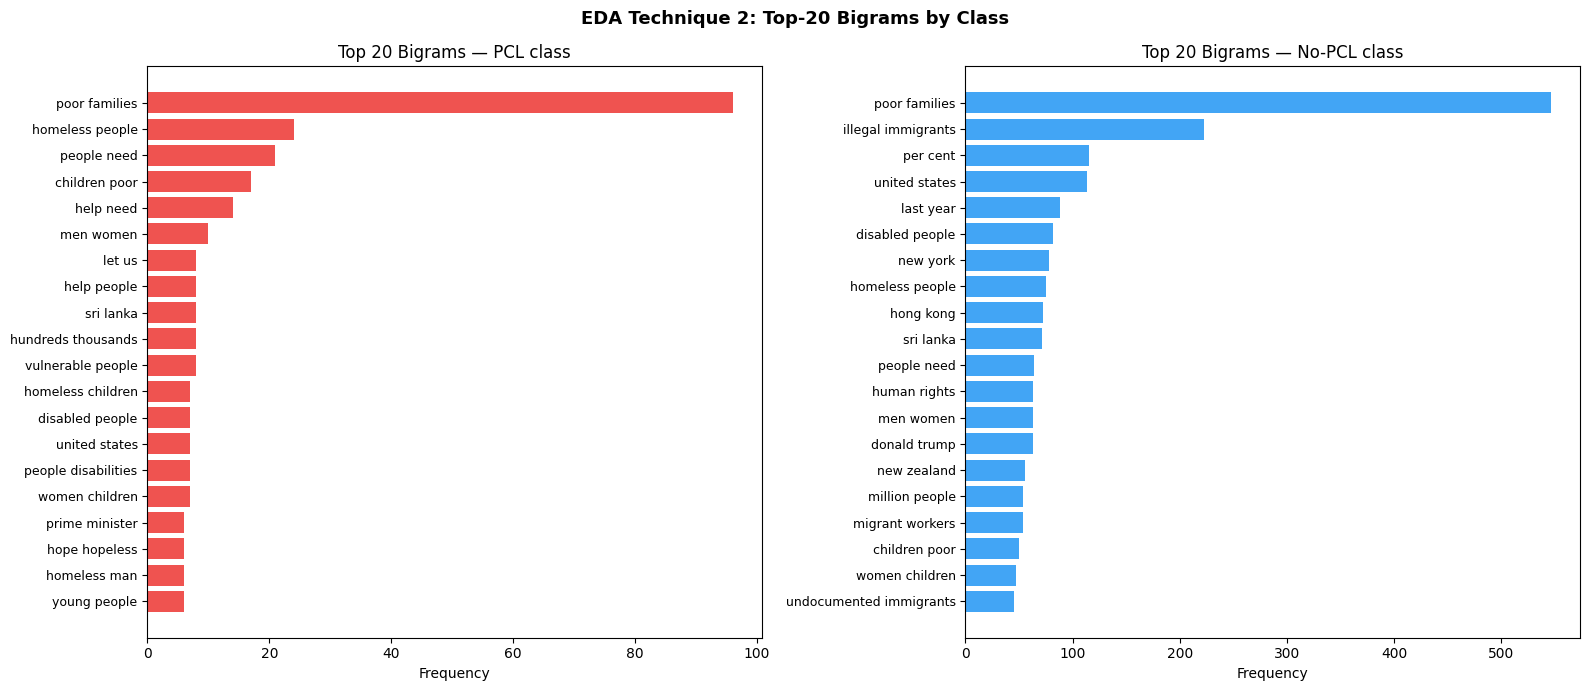

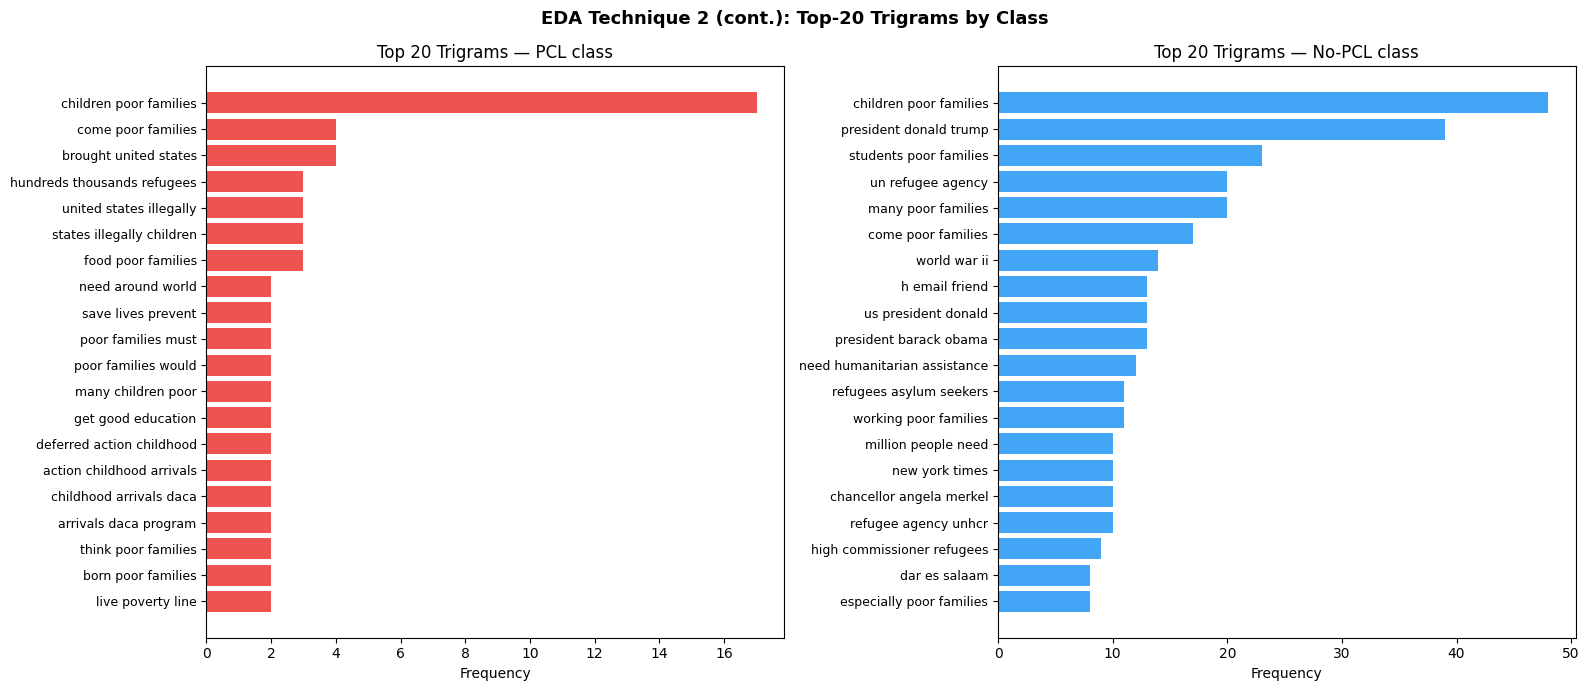

Top 15 unigrams — PCL  : [('people',), ('need',), ('poor',), ('children',), ('families',), ('homeless',), ('said',), ('women',), ('help',), ('would',), ('refugees',), ('life',), ('disabled',), ('vulnerable',), ('many',)]
Top 15 unigrams — No-PCL: [('said',), ('people',), ('women',), ('immigrants',), ('families',), ('vulnerable',), ('need',), ('disabled',), ('poor',), ('also',), ('refugees',), ('homeless',), ('one',), ('children',), ('new',)]

Bigrams in PCL top-20 but NOT in No-PCL top-20: ['help need', 'let us', 'help people', 'hundreds thousands', 'vulnerable people', 'homeless children', 'people disabilities', 'prime minister', 'hope hopeless', 'homeless man', 'young people']
Trigrams in PCL top-20 but NOT in No-PCL top-20: ['brought united states', 'hundreds thousands refugees', 'united states illegally', 'states illegally children', 'food poor families', 'need around world', 'save lives prevent', 'poor families must', 'poor families would', 'many children poor', 'get good educatio

In [9]:
# EDA Technique 2: N-gram Frequency Analysis by Class
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams as nltk_ngrams

nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

STOPWORDS = set(stopwords.words('english'))

def get_top_ngrams(texts, n=2, top_k=20):
    tokens = []
    for text in texts:
        words = [w.lower() for w in word_tokenize(str(text))
                 if w.isalpha() and w.lower() not in STOPWORDS]
        tokens.extend(nltk_ngrams(words, n))
    return Counter(tokens).most_common(top_k)

pcl_texts   = train_df[train_df['label']==1]['text']
nopcl_texts = train_df[train_df['label']==0]['text']

# --- Bigrams ---
pcl_bigrams   = get_top_ngrams(pcl_texts,   n=2, top_k=20)
nopcl_bigrams = get_top_ngrams(nopcl_texts, n=2, top_k=20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('EDA Technique 2: Top-20 Bigrams by Class', fontsize=13, fontweight='bold')

for ax, data, title, color in [
    (axes[0], pcl_bigrams,   'PCL class',    '#EF5350'),
    (axes[1], nopcl_bigrams, 'No-PCL class', '#42A5F5'),
]:
    labels_ng = [' '.join(ng) for ng, _ in data]
    counts_ng = [c for _, c in data]
    ax.barh(labels_ng[::-1], counts_ng[::-1], color=color)
    ax.set_title(f'Top 20 Bigrams — {title}')
    ax.set_xlabel('Frequency')
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('eda_technique2.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Trigrams ---
pcl_trigrams   = get_top_ngrams(pcl_texts,   n=3, top_k=20)
nopcl_trigrams = get_top_ngrams(nopcl_texts, n=3, top_k=20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('EDA Technique 2 (cont.): Top-20 Trigrams by Class', fontsize=13, fontweight='bold')

for ax, data, title, color in [
    (axes[0], pcl_trigrams,   'PCL class',    '#EF5350'),
    (axes[1], nopcl_trigrams, 'No-PCL class', '#42A5F5'),
]:
    labels_ng = [' '.join(ng) for ng, _ in data]
    counts_ng = [c for _, c in data]
    ax.barh(labels_ng[::-1], counts_ng[::-1], color=color)
    ax.set_title(f'Top 20 Trigrams — {title}')
    ax.set_xlabel('Frequency')
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('eda_technique2_trigrams.png', dpi=150, bbox_inches='tight')
plt.show()

# Unigrams
print("Top 15 unigrams — PCL  :", [w for w,_ in get_top_ngrams(pcl_texts,   n=1, top_k=15)])
print("Top 15 unigrams — No-PCL:", [w for w,_ in get_top_ngrams(nopcl_texts, n=1, top_k=15)])

# Bigrams unique to PCL (appear in PCL top-20 but not in No-PCL top-20)
nopcl_set = set(' '.join(ng) for ng,_ in nopcl_bigrams)
pcl_unique = [' '.join(ng) for ng,_ in pcl_bigrams if ' '.join(ng) not in nopcl_set]
print(f"\nBigrams in PCL top-20 but NOT in No-PCL top-20: {pcl_unique}")

# Trigrams unique to PCL
nopcl_tri_set = set(' '.join(ng) for ng,_ in nopcl_trigrams)
pcl_tri_unique = [' '.join(ng) for ng,_ in pcl_trigrams if ' '.join(ng) not in nopcl_tri_set]
print(f"Trigrams in PCL top-20 but NOT in No-PCL top-20: {pcl_tri_unique}")

**EDA Technique 2 — Analysis & Impact**

*Analysis:* The n-gram analysis reveals that PCL language is characterised by bigrams expressing paternalistic framing around vulnerable groups (e.g. "people need", "help need", "hope hopeless"), while No-PCL text uses more neutral, factual language. However, there is substantial lexical overlap between classes; most high-frequency bigrams appear in both, and the discriminating phrases are domain keywords (e.g. community-related terms) that appear in both positive and negative examples.

*Impact Statement:* The large lexical overlap between classes means a simple keyword classifier would achieve poor recall on PCL examples. This motivates the use of a contextual Transformer model (**RoBERTa-base**) that can capture subtle pragmatic framing — not just surface keywords — that distinguishes patronising from neutral language about vulnerable communities.

## 3. Model Components

### Proposed Approach: RoBERTa-base + Imbalance Handling + Threshold Tuning

Two motivated deviations from the RoBERTa-base baseline (F1=0.48):
1. **Imbalance handling** — we compare two strategies identified from EDA (~10:1 class ratio):
   - **Focal Loss** (γ=2, α=0.75): down-weights easy negatives so gradient signal concentrates on hard PCL examples
   - **Upsampling**: duplicate minority-class (PCL) training examples to balance class ratio, then train with standard BCE
2. **Threshold tuning**: grid-search the decision threshold on the dev set to maximise positive-class F1

#### Reported Baseline
The task organisers report **RoBERTa-base F1 = 0.48** on the official dev set (and 0.49 on test set), using standard cross-entropy fine-tuning. This is our performance floor.

In [10]:
# 3.1 — PCLDataset with dynamic padding (pads per-batch, not to global max_len)
class PCLDataset(Dataset):
    """
    Tokenises texts at init but does NOT pad — padding is deferred to collate_fn
    so each batch is padded only to its longest sequence, avoiding wasted compute.
    Pass labels=None for the unlabelled test set.
    """
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.labels = labels
        # tokenize without padding; truncate to max_len; return plain lists (not tensors)
        self.encodings = tokenizer(
            list(texts),
            padding=False,
            truncation=True,
            max_length=max_len,
        )

    def __len__(self):
        return len(self.encodings['input_ids'])

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item


def dynamic_collate_fn(batch):
    """
    Collate function that dynamically pads each batch to the longest sequence
    in that batch (instead of a fixed max_len). This avoids training on pure
    padding tokens for short-text batches, saving compute and memory.
    """
    has_labels = 'labels' in batch[0]
    # Separate labels before padding
    labels = torch.stack([ex.pop('labels') for ex in batch]) if has_labels else None

    # Find the max length in this batch
    max_len = max(ex['input_ids'].size(0) for ex in batch)

    # Pad each key: input_ids with pad_token_id=1 (RoBERTa), attention_mask with 0
    padded = {}
    for key in batch[0].keys():
        pad_value = 1 if key == 'input_ids' else 0
        padded[key] = torch.stack([
            F.pad(ex[key], (0, max_len - ex[key].size(0)), value=pad_value)
            for ex in batch
        ])

    if labels is not None:
        padded['labels'] = labels
    return padded

In [11]:
# 3.2 — Focal Loss: down-weights easy negatives so the model focuses on hard PCL examples
class FocalLoss(nn.Module):
    """
    Binary focal loss:  FL = -alpha_t * (1 - p_t)^gamma * log(p_t)
      alpha=0.75  — upweights the minority PCL class (positive gets 0.75, negative gets 0.25)
      gamma=2.0   — reduces loss contribution of easy (high-confidence) examples
    """
    def __init__(self, alpha: float = 0.75, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce    = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt     = torch.exp(-bce)                              # probability of correct class
        # alpha weighting: alpha for positive class, (1-alpha) for negative class
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal   = alpha_t * (1 - pt) ** self.gamma * bce
        return focal.mean()


# 3.3 — PCL classifier: encoder → [CLS] pooling → linear head
class PCLClassifier(nn.Module):
    def __init__(self, model_name: str = 'roberta-base', dropout: float = 0.1):
        super().__init__()
        self.encoder    = AutoModel.from_pretrained(model_name)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.encoder.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask, token_type_ids=None, **kwargs):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        cls_rep = outputs.last_hidden_state[:, 0, :]   # (B, H) — [CLS] token
        logits  = self.classifier(self.dropout(cls_rep)).squeeze(-1)  # (B,)
        return logits

In [12]:
# 3.4 — Training and evaluation helper functions

def train_one_epoch(model, loader, optimizer, scheduler, criterion, device):
    """One full pass over the training set. Returns mean loss."""
    model.train()
    total_loss = 0.0
    for batch in loader:
        labels = batch.pop('labels').to(device)
        batch  = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()
        logits = model(**batch)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, device, criterion=None, threshold: float = 0.5):
    """
    Evaluate on a labelled DataLoader.
    Returns: (f1, preds_list, labels_list, probs_list, val_loss)
    val_loss is None if criterion is not provided.
    """
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    total_loss = 0.0
    n_batches = 0
    with torch.no_grad():
        for batch in loader:
            labels = batch.pop('labels').to(device)
            batch  = {k: v.to(device) for k, v in batch.items()}
            logits = model(**batch)
            if criterion is not None:
                total_loss += criterion(logits, labels).item()
                n_batches += 1
            probs  = torch.sigmoid(logits).cpu().numpy()
            preds  = (probs >= threshold).astype(int)
            all_probs.extend(probs.tolist())
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.cpu().numpy().astype(int).tolist())
    f1 = f1_score(all_labels, all_preds)
    val_loss = total_loss / n_batches if n_batches > 0 else None
    return f1, all_preds, all_labels, all_probs, val_loss


def predict_test(model, loader, device, threshold: float = 0.5):
    """Run inference on an unlabelled DataLoader. Returns list of 0/1 predictions."""
    model.eval()
    all_preds = []
    with torch.no_grad():
        for batch in loader:
            batch  = {k: v.to(device) for k, v in batch.items()}
            logits = model(**batch)
            probs  = torch.sigmoid(logits).cpu().numpy()
            preds  = (probs >= threshold).astype(int)
            all_preds.extend(preds.tolist())
    return all_preds


def sweep_threshold(probs, labels, lo: float = 0.30, hi: float = 0.70, step: float = 0.01):
    """
    Grid-search threshold in [lo, hi] to maximise positive-class F1.
    Returns: (best_threshold, best_f1, list_of_(threshold, f1)_pairs)
    """
    probs_arr    = np.array(probs)
    best_thresh  = 0.5
    best_f1      = 0.0
    results      = []
    for t in np.arange(lo, hi + step / 2, step):
        t = round(t, 3)
        preds = (probs_arr >= t).astype(int)
        f1    = f1_score(labels, preds)
        results.append((t, f1))
        if f1 > best_f1:
            best_f1, best_thresh = f1, t
    return best_thresh, best_f1, results

print("Model components defined: PCLDataset, FocalLoss, PCLClassifier, train/eval helpers.")

Model components defined: PCLDataset, FocalLoss, PCLClassifier, train/eval helpers.


## 4. Novel Model Training

We train two variants of RoBERTa-base — one with **Focal Loss** and one with **Upsampling + BCE** — then compare dev F1 to pick the best imbalance-handling strategy.

Shared training configuration:
- Model: `roberta-base` (~125M parameters)
- Optimiser: AdamW (lr=2e-5, weight_decay=0.01)
- Scheduler: Linear warmup (10%) + linear decay
- Batch size: 16 | Max seq length: 256 | Epochs: up to 10 (early stopping, patience=3)

In [13]:
# 4.0 — Set model checkpoint path
# On Colab: mount Google Drive and save there
# On local/cloud GPU: save to current working directory
try:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = '/content/drive/MyDrive/'
except ImportError:
    SAVE_DIR = './'

SAVE_PATH_FL = SAVE_DIR + 'best_roberta_focal.pt'
SAVE_PATH_UP = SAVE_DIR + 'best_roberta_upsample.pt'
print(f"Focal loss checkpoint : {SAVE_PATH_FL}")
print(f"Upsampling checkpoint : {SAVE_PATH_UP}")

Focal loss checkpoint : ./best_roberta_focal.pt
Upsampling checkpoint : ./best_roberta_upsample.pt


In [14]:
# 4.1 — Shared hyperparameters and DataLoaders
MODEL_NAME = 'roberta-base'
BATCH_SIZE = 16
MAX_LEN    = 256
LR         = 2e-5
EPOCHS     = 10
PATIENCE   = 3

print("Loading RoBERTa-base tokenizer…")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Training set (original class distribution)
train_ds = PCLDataset(train_df['text'].tolist(), train_df['label'].tolist(), tokenizer, MAX_LEN)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2,
                      pin_memory=True, collate_fn=dynamic_collate_fn)

# Validation set — used for early stopping during training
val_ds = PCLDataset(val_df['text'].tolist(), val_df['label'].tolist(), tokenizer, MAX_LEN)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2,
                    pin_memory=True, collate_fn=dynamic_collate_fn)

# Dev set — reserved exclusively for threshold tuning (never seen during training)
dev_ds = PCLDataset(dev_df['text'].tolist(), dev_df['label'].tolist(), tokenizer, MAX_LEN)
dev_dl = DataLoader(dev_ds, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2,
                    pin_memory=True, collate_fn=dynamic_collate_fn)

# Upsampled training set: duplicate PCL examples to roughly balance classes
pcl_df   = train_df[train_df['label'] == 1]
nopcl_df = train_df[train_df['label'] == 0]
upsample_factor = len(nopcl_df) // len(pcl_df)   # ~9x
train_up_df = pd.concat([nopcl_df, pd.concat([pcl_df] * upsample_factor)], ignore_index=True)
train_up_df = train_up_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

train_up_ds = PCLDataset(train_up_df['text'].tolist(), train_up_df['label'].tolist(), tokenizer, MAX_LEN)
train_up_dl = DataLoader(train_up_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2,
                         pin_memory=True, collate_fn=dynamic_collate_fn)

print(f"\nOriginal train : {len(train_df):,} examples | PCL={train_df['label'].sum():,} ({100*train_df['label'].mean():.1f}%)")
print(f"Upsampled train: {len(train_up_df):,} examples | PCL={train_up_df['label'].sum():,} ({100*train_up_df['label'].mean():.1f}%)")
print(f"Val (early stop): {len(val_df):,}   examples")
print(f"Dev (thresh tune): {len(dev_df):,}  examples")
print(f"\nTrain batches (original): {len(train_dl)}, Train batches (upsampled): {len(train_up_dl)}")
print(f"Val batches: {len(val_dl)}, Dev batches: {len(dev_dl)}")
print(f"\n→ Using dynamic padding: each batch padded to its longest sequence (not fixed {MAX_LEN})")

Loading RoBERTa-base tokenizer…

Original train : 7,537 examples | PCL=715 (9.5%)
Upsampled train: 13,257 examples | PCL=6,435 (48.5%)
Val (early stop): 838   examples
Dev (thresh tune): 2,094  examples

Train batches (original): 472, Train batches (upsampled): 829
Val batches: 27, Dev batches: 66

→ Using dynamic padding: each batch padded to its longest sequence (not fixed 256)


In [15]:
# 4.2A — Variant A: RoBERTa-base + Focal Loss
print("=" * 60)
print("VARIANT A: RoBERTa-base + Focal Loss (γ=2, α=0.75)")
print("=" * 60)

model_fl     = PCLClassifier(MODEL_NAME).to(DEVICE)
criterion_fl = FocalLoss(alpha=0.75, gamma=2.0)
optimizer_fl = torch.optim.AdamW(model_fl.parameters(), lr=LR, weight_decay=0.01)

total_steps_fl = len(train_dl) * EPOCHS
scheduler_fl   = get_linear_schedule_with_warmup(
    optimizer_fl,
    num_warmup_steps=int(0.1 * total_steps_fl),
    num_training_steps=total_steps_fl
)

print(f"Model parameters : {sum(p.numel() for p in model_fl.parameters()):,}")
print(f"Total train steps: {total_steps_fl:,}  (warmup: {int(0.1*total_steps_fl):,})")

VARIANT A: RoBERTa-base + Focal Loss (γ=2, α=0.75)


Loading weights: 100%|██████████| 197/197 [00:02<00:00, 92.35it/s, Materializing param=encoder.layer.11.output.dense.weight]               
RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters : 124,646,401
Total train steps: 4,720  (warmup: 472)


In [16]:
# 4.3A — Train Variant A (Focal Loss) — early stopping on val LOSS
best_fl_loss = float('inf')
best_fl_f1   = 0.0
no_improve   = 0
history_fl   = []

print("Training Variant A: RoBERTa-base + Focal Loss…\n")
for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model_fl, train_dl, optimizer_fl, scheduler_fl, criterion_fl, DEVICE)
    val_f1, _, _, _, val_loss = evaluate(model_fl, val_dl, DEVICE, criterion=criterion_fl, threshold=0.5)
    history_fl.append({'epoch': epoch+1, 'loss': train_loss, 'val_loss': val_loss, 'val_f1': val_f1})
    print(f"Epoch {epoch+1}/{EPOCHS}  |  train_loss={train_loss:.4f}  |  val_loss={val_loss:.4f}  |  val F1={val_f1:.4f}", end='')

    if val_loss < best_fl_loss:
        best_fl_loss = val_loss
        best_fl_f1 = val_f1
        torch.save(model_fl.state_dict(), SAVE_PATH_FL)
        no_improve = 0
        print(f"  ← new best ✓")
    else:
        no_improve += 1
        print(f"  (no improve {no_improve}/{PATIENCE})")
        if no_improve >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch+1}.")
            break

print(f"\nVariant A best val loss: {best_fl_loss:.4f}  (val F1 at that point: {best_fl_f1:.4f})")

Training Variant A: RoBERTa-base + Focal Loss…

Epoch 1/10  |  train_loss=0.0423  |  val_loss=0.0348  |  val F1=0.0706  ← new best ✓
Epoch 2/10  |  train_loss=0.0279  |  val_loss=0.0259  |  val F1=0.5795  ← new best ✓
Epoch 3/10  |  train_loss=0.0161  |  val_loss=0.0284  |  val F1=0.5507  (no improve 1/3)
Epoch 4/10  |  train_loss=0.0068  |  val_loss=0.0631  |  val F1=0.4908  (no improve 2/3)
Epoch 5/10  |  train_loss=0.0018  |  val_loss=0.1569  |  val F1=0.4228  (no improve 3/3)

Early stopping triggered at epoch 5.

Variant A best val loss: 0.0259  (val F1 at that point: 0.5795)


In [17]:
# 4.2B — Variant B: RoBERTa-base + Upsampling + BCE
print("=" * 60)
print("VARIANT B: RoBERTa-base + Upsampling + BCE")
print("=" * 60)

model_up     = PCLClassifier(MODEL_NAME).to(DEVICE)
criterion_up = nn.BCEWithLogitsLoss()
optimizer_up = torch.optim.AdamW(model_up.parameters(), lr=LR, weight_decay=0.01)

total_steps_up = len(train_up_dl) * EPOCHS
scheduler_up   = get_linear_schedule_with_warmup(
    optimizer_up,
    num_warmup_steps=int(0.1 * total_steps_up),
    num_training_steps=total_steps_up
)

print(f"Model parameters : {sum(p.numel() for p in model_up.parameters()):,}")
print(f"Total train steps: {total_steps_up:,}  (warmup: {int(0.1*total_steps_up):,})")
print(f"Note: more steps than Variant A because the upsampled dataset is larger")

VARIANT B: RoBERTa-base + Upsampling + BCE


Loading weights: 100%|██████████| 197/197 [00:02<00:00, 80.75it/s, Materializing param=encoder.layer.11.output.dense.weight]               
RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters : 124,646,401
Total train steps: 8,290  (warmup: 829)
Note: more steps than Variant A because the upsampled dataset is larger


In [18]:
# 4.3B — Train Variant B (Upsampling + BCE) — early stopping on val LOSS
best_up_loss = float('inf')
best_up_f1   = 0.0
no_improve   = 0
history_up   = []

print("Training Variant B: RoBERTa-base + Upsampling + BCE…\n")
for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model_up, train_up_dl, optimizer_up, scheduler_up, criterion_up, DEVICE)
    val_f1, _, _, _, val_loss = evaluate(model_up, val_dl, DEVICE, criterion=criterion_up, threshold=0.5)
    history_up.append({'epoch': epoch+1, 'loss': train_loss, 'val_loss': val_loss, 'val_f1': val_f1})
    print(f"Epoch {epoch+1}/{EPOCHS}  |  train_loss={train_loss:.4f}  |  val_loss={val_loss:.4f}  |  val F1={val_f1:.4f}", end='')

    if val_loss < best_up_loss:
        best_up_loss = val_loss
        best_up_f1 = val_f1
        torch.save(model_up.state_dict(), SAVE_PATH_UP)
        no_improve = 0
        print(f"  ← new best ✓")
    else:
        no_improve += 1
        print(f"  (no improve {no_improve}/{PATIENCE})")
        if no_improve >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch+1}.")
            break

print(f"\nVariant B best val loss: {best_up_loss:.4f}  (val F1 at that point: {best_up_f1:.4f})")

Training Variant B: RoBERTa-base + Upsampling + BCE…

Epoch 1/10  |  train_loss=0.4113  |  val_loss=0.5933  |  val F1=0.4242  ← new best ✓
Epoch 2/10  |  train_loss=0.1476  |  val_loss=0.5531  |  val F1=0.5357  ← new best ✓
Epoch 3/10  |  train_loss=0.0462  |  val_loss=0.8160  |  val F1=0.4920  (no improve 1/3)
Epoch 4/10  |  train_loss=0.0197  |  val_loss=0.8043  |  val F1=0.4892  (no improve 2/3)
Epoch 5/10  |  train_loss=0.0073  |  val_loss=0.7756  |  val F1=0.5430  (no improve 3/3)

Early stopping triggered at epoch 5.

Variant B best val loss: 0.5531  (val F1 at that point: 0.5357)


In [19]:
# 4.4 — Compare variants on the official dev set and select BestModel
# Load best checkpoints and evaluate on dev (which was NOT used during training)
model_fl.load_state_dict(torch.load(SAVE_PATH_FL, map_location=DEVICE))
model_up.load_state_dict(torch.load(SAVE_PATH_UP, map_location=DEVICE))

dev_f1_fl, _, _, _, _ = evaluate(model_fl, dev_dl, DEVICE, threshold=0.5)
dev_f1_up, _, _, _, _ = evaluate(model_up, dev_dl, DEVICE, threshold=0.5)

print("=" * 60)
print("VARIANT COMPARISON")
print("=" * 60)
print(f"  Variant A (Focal Loss)   — val F1: {best_fl_f1:.4f}  |  dev F1: {dev_f1_fl:.4f}")
print(f"  Variant B (Upsampling)   — val F1: {best_up_f1:.4f}  |  dev F1: {dev_f1_up:.4f}")
print(f"  Baseline  (reported)     —                  dev F1: 0.4800")

if dev_f1_fl >= dev_f1_up:
    BEST_VARIANT = 'focal'
    model = model_fl
    SAVE_PATH = SAVE_PATH_FL
    best_dev_f1 = dev_f1_fl
    print(f"\n→ Variant A (Focal Loss) wins on dev — using as BestModel")
else:
    BEST_VARIANT = 'upsample'
    model = model_up
    SAVE_PATH = SAVE_PATH_UP
    best_dev_f1 = dev_f1_up
    print(f"\n→ Variant B (Upsampling) wins on dev — using as BestModel")

VARIANT COMPARISON
  Variant A (Focal Loss)   — val F1: 0.5795  |  dev F1: 0.5499
  Variant B (Upsampling)   — val F1: 0.5357  |  dev F1: 0.5952
  Baseline  (reported)     —                  dev F1: 0.4800

→ Variant B (Upsampling) wins on dev — using as BestModel


## 5. Threshold Tuning

Post-training: sweep the decision threshold over [0.30, 0.70] on the dev set
to find the value that maximises positive-class F1 (rather than defaulting to 0.5).

We apply threshold tuning to the **winning variant** from the comparison above.

Best threshold        : 0.43
Dev F1 (tuned thresh) : 0.6005
Dev F1 (thresh=0.5)   : 0.5952
Gain from tuning      : +0.0052


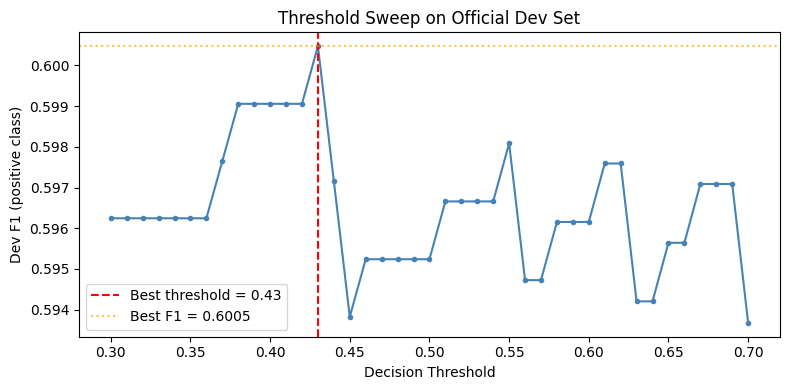


BEST_THRESHOLD set to: 0.43


In [20]:
# 5.1 — Threshold tuning on the winning variant
_, _, dev_labels_arr, dev_probs_arr, _ = evaluate(model, dev_dl, DEVICE, threshold=0.5)

best_thresh, best_f1_tuned, sweep_results = sweep_threshold(dev_probs_arr, dev_labels_arr)

print(f"Best threshold        : {best_thresh:.2f}")
print(f"Dev F1 (tuned thresh) : {best_f1_tuned:.4f}")
print(f"Dev F1 (thresh=0.5)   : {best_dev_f1:.4f}")
print(f"Gain from tuning      : {best_f1_tuned - best_dev_f1:+.4f}")

# Plot threshold sweep
thresholds_plot = [r[0] for r in sweep_results]
f1s_plot        = [r[1] for r in sweep_results]

plt.figure(figsize=(8, 4))
plt.plot(thresholds_plot, f1s_plot, marker='.', color='steelblue')
plt.axvline(best_thresh, color='red', linestyle='--', label=f'Best threshold = {best_thresh}')
plt.axhline(best_f1_tuned, color='orange', linestyle=':', alpha=0.7, label=f'Best F1 = {best_f1_tuned:.4f}')
plt.xlabel('Decision Threshold')
plt.ylabel('Dev F1 (positive class)')
plt.title('Threshold Sweep on Official Dev Set')
plt.legend(); plt.tight_layout()
plt.savefig('threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

BEST_THRESHOLD = best_thresh
print(f"\nBEST_THRESHOLD set to: {BEST_THRESHOLD}")

## 6. Ablation Study

Systematically compare components to quantify each one's contribution.

| Variant | Description |
|---|---|
| Baseline (RoBERTa-base) | Reported by task organisers (BCE, thresh=0.5) |
| RoBERTa + Focal Loss + thresh=0.5 | Variant A from training |
| RoBERTa + Upsampling + BCE + thresh=0.5 | Variant B from training |
| **RoBERTa + [winner] + tuned thresh** | **BestModel** |

In [21]:
# 6.1 — Ablation: also apply threshold tuning to the losing variant for completeness
# Load the losing variant's checkpoint and sweep its threshold
if BEST_VARIANT == 'focal':
    loser_model = model_up
    loser_model.load_state_dict(torch.load(SAVE_PATH_UP, map_location=DEVICE))
    _, _, _, loser_probs, _ = evaluate(loser_model, dev_dl, DEVICE, threshold=0.5)
    _, loser_f1_tuned, _ = sweep_threshold(loser_probs, dev_labels_arr)
    fl_f1_tuned = best_f1_tuned
    up_f1_tuned = loser_f1_tuned
else:
    loser_model = model_fl
    loser_model.load_state_dict(torch.load(SAVE_PATH_FL, map_location=DEVICE))
    _, _, _, loser_probs, _ = evaluate(loser_model, dev_dl, DEVICE, threshold=0.5)
    _, loser_f1_tuned, _ = sweep_threshold(loser_probs, dev_labels_arr)
    fl_f1_tuned = loser_f1_tuned
    up_f1_tuned = best_f1_tuned

print("Threshold-tuned F1 for both variants:")
print(f"  Focal Loss (tuned) : {fl_f1_tuned:.4f}")
print(f"  Upsampling (tuned) : {up_f1_tuned:.4f}")

Threshold-tuned F1 for both variants:
  Focal Loss (tuned) : 0.5610
  Upsampling (tuned) : 0.6005


In [22]:
# 6.2 — Ablation summary table
# Note: dev_f1_fl and dev_f1_up are the dev-set F1 scores at threshold=0.5
# computed in cell 4.4 (variant comparison). We use these — NOT the val F1
# from early stopping (best_fl_f1 / best_up_f1) — so all rows are comparable.
ablation_df = pd.DataFrame([
    {'Variant': 'Baseline — RoBERTa-base + BCE + thresh=0.5 (reported)',              'Dev F1': 0.48},
    {'Variant': 'RoBERTa-base + Focal Loss + thresh=0.5',                             'Dev F1': round(dev_f1_fl, 4)},
    {'Variant': 'RoBERTa-base + Upsampling + BCE + thresh=0.5',                       'Dev F1': round(dev_f1_up, 4)},
    {'Variant': 'RoBERTa-base + Focal Loss + tuned thresh',                           'Dev F1': round(fl_f1_tuned, 4)},
    {'Variant': 'RoBERTa-base + Upsampling + BCE + tuned thresh',                     'Dev F1': round(up_f1_tuned, 4)},
])

# Mark BestModel
best_idx = ablation_df['Dev F1'].idxmax()
ablation_df.loc[best_idx, 'Variant'] += '  ← BestModel'

print(ablation_df.to_string(index=False))
print(f"\n→ Best overall: {ablation_df.loc[best_idx, 'Variant']} with F1 = {ablation_df.loc[best_idx, 'Dev F1']}")

                                                    Variant  Dev F1
      Baseline — RoBERTa-base + BCE + thresh=0.5 (reported)  0.4800
                     RoBERTa-base + Focal Loss + thresh=0.5  0.5499
               RoBERTa-base + Upsampling + BCE + thresh=0.5  0.5952
                   RoBERTa-base + Focal Loss + tuned thresh  0.5610
RoBERTa-base + Upsampling + BCE + tuned thresh  ← BestModel  0.6005

→ Best overall: RoBERTa-base + Upsampling + BCE + tuned thresh  ← BestModel with F1 = 0.6005


## 7. Evaluation and Error Analysis (Exercise 5.2)

### 7.1 Global Evaluation
Dev F1 reported above (BestModel). Test set predictions generated in Section 8.

### 7.2 Local Evaluation
- Confusion matrix  
- False positive / false negative inspection  
- Precision-Recall curve  

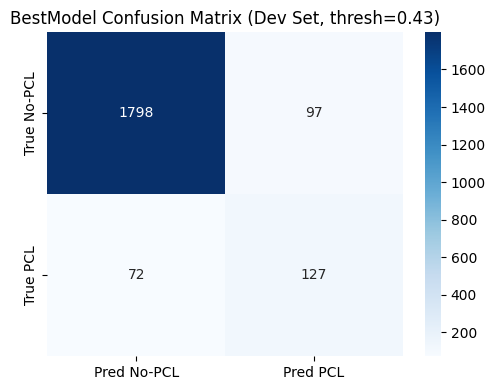

              precision    recall  f1-score   support

      No PCL       0.96      0.95      0.96      1895
         PCL       0.57      0.64      0.60       199

    accuracy                           0.92      2094
   macro avg       0.76      0.79      0.78      2094
weighted avg       0.92      0.92      0.92      2094



In [23]:
# 7.1 — Confusion matrix on dev set (BestModel with tuned threshold)
_, novel_preds_list, dev_labels_final, dev_probs_final, _ = evaluate(
    model, dev_dl, DEVICE, threshold=BEST_THRESHOLD)

novel_preds_arr  = np.array(novel_preds_list)
dev_labels_np    = np.array(dev_labels_final)

cm = confusion_matrix(dev_labels_final, novel_preds_list)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred No-PCL', 'Pred PCL'],
            yticklabels=['True No-PCL', 'True PCL'], ax=ax)
ax.set_title(f'BestModel Confusion Matrix (Dev Set, thresh={BEST_THRESHOLD})')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(dev_labels_final, novel_preds_list,
                             target_names=['No PCL', 'PCL']))

In [24]:
# 7.2 — False Positive and False Negative inspection
dev_df_eval = dev_df.copy()
dev_df_eval['novel_pred'] = novel_preds_arr

fp_examples = dev_df_eval[(dev_df_eval['label'] == 0) & (dev_df_eval['novel_pred'] == 1)].head(5)
fn_examples = dev_df_eval[(dev_df_eval['label'] == 1) & (dev_df_eval['novel_pred'] == 0)].head(5)

print("=" * 70)
print("FALSE POSITIVES — predicted PCL, actually No-PCL")
print("=" * 70)
for i, (_, row) in enumerate(fp_examples.iterrows(), 1):
    print(f"\n[FP {i}] keyword={row['keyword']}")
    print(row['text'][:400])

print("\n" + "=" * 70)
print("FALSE NEGATIVES — missed PCL (predicted No-PCL, actually PCL)")
print("=" * 70)
for i, (_, row) in enumerate(fn_examples.iterrows(), 1):
    print(f"\n[FN {i}] keyword={row['keyword']}")
    print(row['text'][:400])

FALSE POSITIVES — predicted PCL, actually No-PCL

[FP 1] keyword=poor-families
Marcos said the government should help poor families that try every possible means to survive. With Joel Zurbano <h> More from this Category:

[FP 2] keyword=disabled
A crew of disabled athletes will be tackling this weekend's Chattanooga Waterfront Triathlon to show others with disabilities they, too, can participate in a healthy, active lifestyle.

[FP 3] keyword=homeless
" The proceeds from Lady Lucan's estate will help Shelter to continue fighting bad housing and homelessness. "

[FP 4] keyword=disabled
The Jali family in Brown's Farm was elated as the City of Cape Town donated wheelchairs to their disabled members.

[FP 5] keyword=hopeless
" So we do need to heal ourselves as an Aboriginal Torres Strait islander community, but also as a nation. " <h> A life of hope, not hopelessness

FALSE NEGATIVES — missed PCL (predicted No-PCL, actually PCL)

[FN 1] keyword=homeless
His present " chambers " may be qu

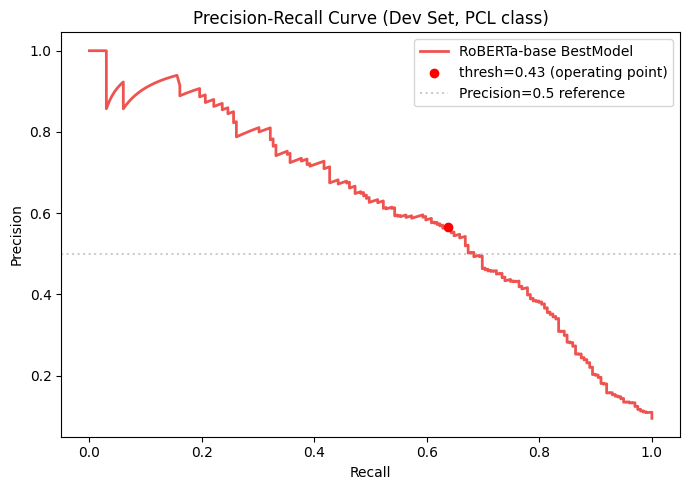

Average Precision (AP) on dev set: 0.6136

Operating point (thresh=0.43): Precision=0.567, Recall=0.638, F1=0.6005


In [25]:
# 7.3 — Precision-Recall curve
prec_arr, rec_arr, pr_thresholds = precision_recall_curve(dev_labels_final, dev_probs_final)

plt.figure(figsize=(7, 5))
plt.plot(rec_arr, prec_arr, lw=2, color='#EF5350', label='RoBERTa-base BestModel')

# Mark the operating point at BEST_THRESHOLD
if len(pr_thresholds) > 0:
    idx = int(np.argmin(np.abs(np.array(pr_thresholds) - BEST_THRESHOLD)))
    plt.scatter([rec_arr[idx]], [prec_arr[idx]], color='red', zorder=5,
                label=f'thresh={BEST_THRESHOLD} (operating point)')

plt.axhline(y=0.5, color='grey', linestyle=':', alpha=0.4, label='Precision=0.5 reference')

plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Dev Set, PCL class)')
plt.legend(); plt.tight_layout()
plt.savefig('pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

from sklearn.metrics import average_precision_score
ap = average_precision_score(dev_labels_final, dev_probs_final)
print(f"Average Precision (AP) on dev set: {ap:.4f}")
print(f"\nOperating point (thresh={BEST_THRESHOLD}): "
      f"Precision={prec_arr[idx]:.3f}, Recall={rec_arr[idx]:.3f}, F1={best_f1_tuned:.4f}")

## 8. Prediction Files (Exercise 5.1)

Generating `dev.txt` and `test.txt` for submission.  
Format: one integer (0 or 1) per line.

In [26]:
# 8.1 — dev.txt: predictions on the official dev set
# novel_preds_list was computed in Section 7 with BEST_THRESHOLD
dev_predictions = novel_preds_arr.tolist()

with open('dev.txt', 'w') as f:
    for pred in dev_predictions:
        f.write(f"{int(pred)}\n")

reported_f1 = f1_score(dev_labels_final, dev_predictions)
print(f"dev.txt written: {len(dev_predictions)} lines")
print(f"Dev F1 (official metric, positive class): {reported_f1:.4f}")
print(f"Baseline comparison: {reported_f1:.4f} vs 0.4800 (RoBERTa-base) → {reported_f1 - 0.48:+.4f}")

dev.txt written: 2094 lines
Dev F1 (official metric, positive class): 0.6005
Baseline comparison: 0.6005 vs 0.4800 (RoBERTa-base) → +0.1205


In [27]:
# 8.2 — test.txt: predictions on the official test set (3,832 examples, no labels)
test_ds = PCLDataset(test_df['text'].tolist(), labels=None,
                     tokenizer=tokenizer, max_len=MAX_LEN)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE * 2, shuffle=False,
                     collate_fn=dynamic_collate_fn)

# Reload best checkpoint
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))

test_predictions = predict_test(model, test_dl, DEVICE, threshold=BEST_THRESHOLD)

with open('test.txt', 'w') as f:
    for pred in test_predictions:
        f.write(f"{int(pred)}\n")

print(f"test.txt written : {len(test_predictions)} lines  (expected 3,832)")
print(len(test_predictions))
assert len(test_predictions) == len(test_df), \
    f"Line count mismatch: {len(test_predictions)} != {len(test_df)}"
print(f"Predicted PCL rate: {sum(test_predictions)/len(test_predictions)*100:.1f}%")

test.txt written : 3832 lines  (expected 3,832)
3832
Predicted PCL rate: 9.8%


In [28]:
# 8.3 — Final format verification
for fname in ['dev.txt', 'test.txt']:
    with open(fname) as fh:
        lines = fh.readlines()
    invalid = [l.strip() for l in lines if l.strip() not in ('0', '1')]
    assert not invalid, f"{fname}: found non-binary values: {invalid[:5]}"
    print(f"✓ {fname}: {len(lines)} lines, all valid 0/1 predictions")

✓ dev.txt: 2094 lines, all valid 0/1 predictions
✓ test.txt: 3832 lines, all valid 0/1 predictions
